In [1]:
import deepxde as dde
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import numpy as np 

from pinn_error.core.pinn import PINNConfig
from pinn_error.core.error_bounds import PINNErrorBoundEstimator
from pinn_error.utils.experiment_factory import ExperimentFactory
from pinn_error.utils.plotting import (plot_experiment_results,
                                       print_error_metrics)
from pinn_error.utils.setup import set_default_device


try:
    sns.set_theme(
        style='whitegrid',
        font='Libertinus Serif',
        font_scale=2,
        rc={
            'axes.facecolor': 'white',
            'figure.facecolor': 'white',
            'mathtext.fontset': 'custom',
            'mathtext.rm': 'Libertinus Serif',
            'mathtext.it': 'Libertinus Serif:italic',
            'mathtext.bf': 'Libertinus Serif:bold',
            'text.usetex': True,
            'font.family': 'serif',
            'font.serif': ['Libertinus Serif'],
        }
    )
except Exception as e:
    print(f"Could not set custom font: {e}")
    sns.set_theme(
        style='whitegrid',
        font_scale=2,
        rc={
            'axes.facecolor': 'white',
            'figure.facecolor': 'white',
        }
    )

dde.config.set_default_float("float64")

set_default_device("cpu")

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


Set the default float type to float64
Using CPU


In [2]:
experiment = ExperimentFactory(
    problem_name="heat",
    fdm_solver_kwargs={
        "nx": 64,
        "nt": 64,
        "ny": 0,
    },
    problem_kwargs={
        "x_min": 0.0,
        "x_max": 1.0,
        "t_max": 1.0,
        "diffusivity": 0.05,
        "frequency": 2,
    },
    pinn_config=PINNConfig(
        num_domain=10_000,
        n_iterations=10_000,
        seed=42,
    ),
    verbose=True
)

Compiling model...
'compile' took 0.000101 s



In [3]:
results = experiment.run_experiment()

Model loaded from cache: /Users/krasowski/Documents/work/pinn_error_estimation_fdm_aycan_base/.venv/lib/python3.13/site-packages/model_zoo/cb2ee0641f1f8be8.pt
PINN training run time: 113.6810 seconds
FDM error estimation run time: 0.0284 seconds
FDM solution run time: 0.0014 seconds (including PINN prediction time: 0.0000 seconds)


In [4]:
x = results['x']
t = results['t']
u_pinn = results["u_pinn"]
u_exact = results["u_true"]
u_fdm = results["u_fdm"]
err_estimated = results["e_res"]
e_true = results["e_true"]

fdm_based_error = u_fdm - u_pinn
e_true = u_exact - u_pinn

nt, nx = len(t), len(x)

In [5]:
time_indices = [1, nt // 4, nt // 2, 3 * (nt-1) // 4, nt - 1]

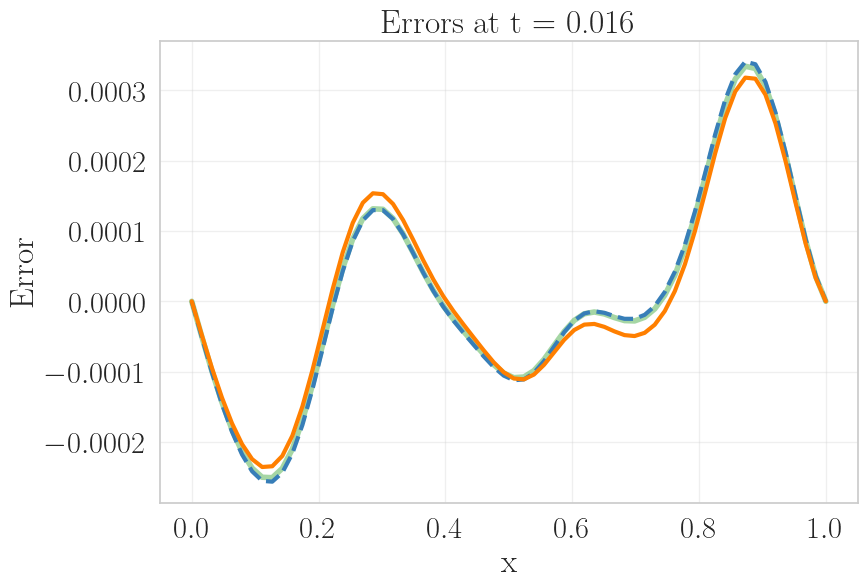

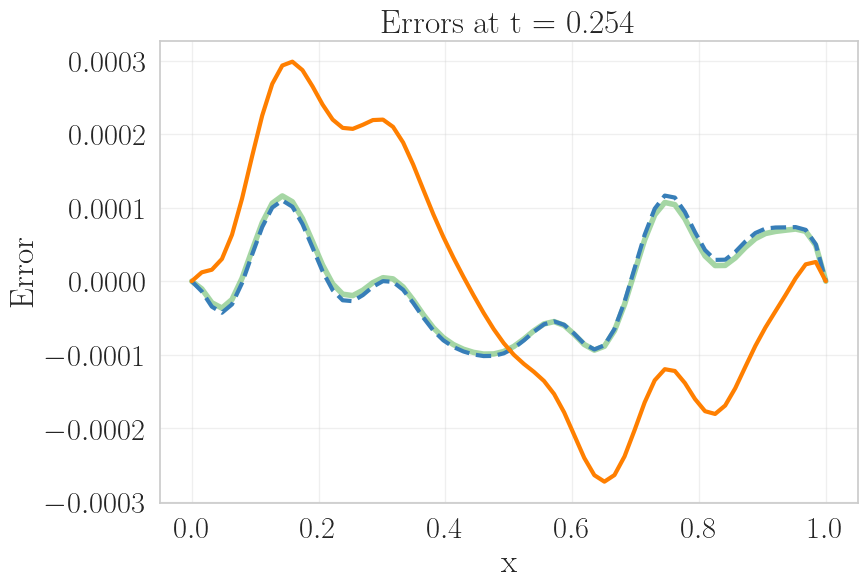

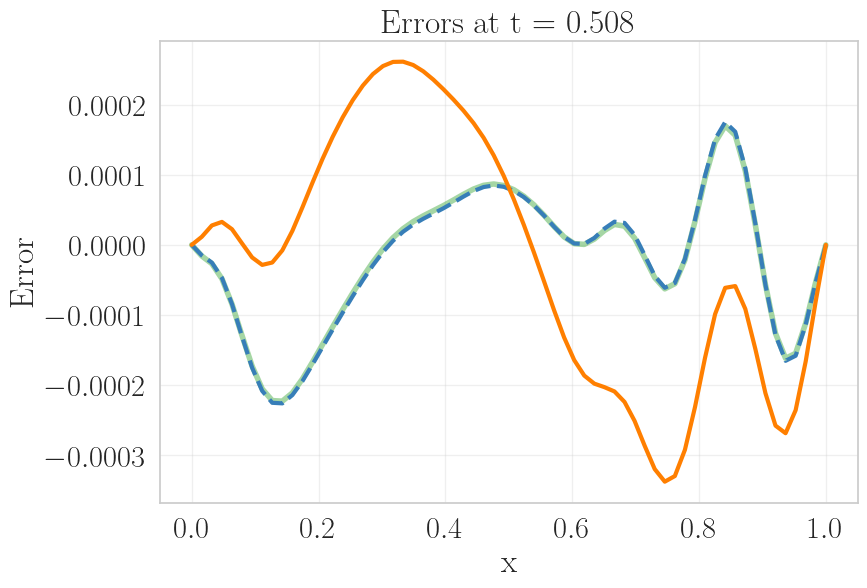

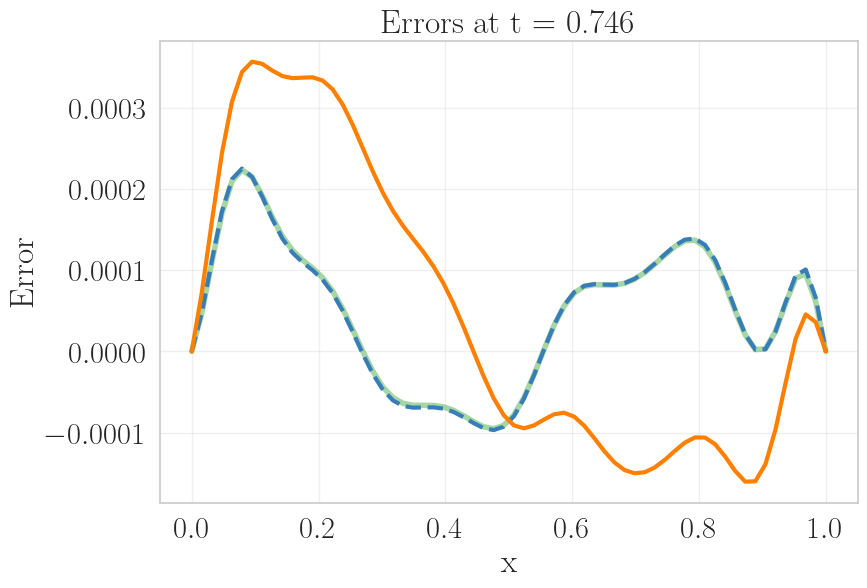

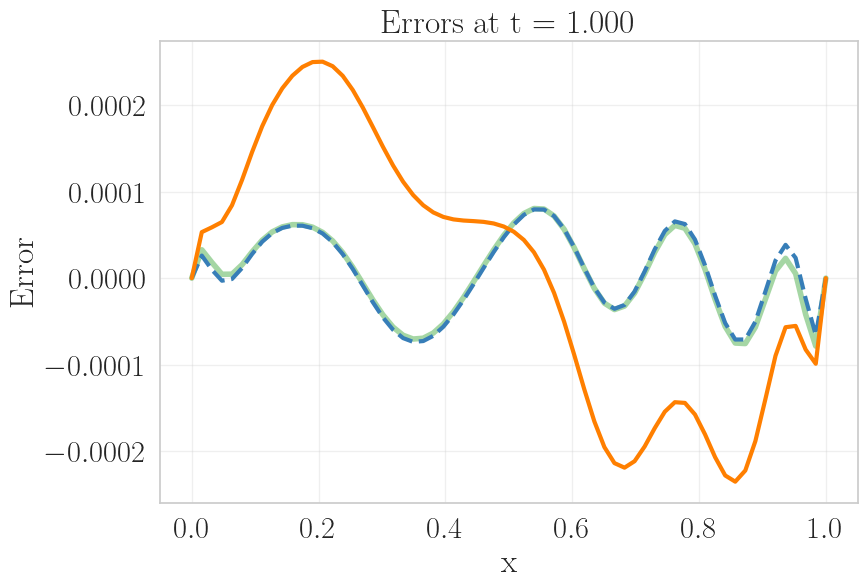

In [6]:
from pathlib import Path
if not Path("../figures/heat_eq_error_comparison/").exists():
    Path("../figures/heat_eq_error_comparison/").mkdir(parents=True, exist_ok=True)

for e, idx in enumerate(time_indices):
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.plot(x, e_true[idx], linestyle="-", color='#4daf4a', lw=4, label=f"$e_{{\\mathrm{{true}}}}$ (True Error)", alpha=0.5)
    ax.plot(x, err_estimated[idx], linestyle="--", color="#377eb8", lw=3, label=f"$e_{{\\mathrm{{res}}}}$ (Residual Est.)")
    ax.plot(x, fdm_based_error[idx], linestyle="-", color='#ff7f00', lw=3, label=f"$e_{{\\mathrm{{fdm}}}}$ (FDM Est.)")
    ax.set_xlabel("x")
    ax.set_ylabel("Error")
    # ax.legend()
    ax.grid(True, alpha=0.3)
    fig.savefig(f"../figures/heat_eq_error_comparison/time_{idx}.pdf", bbox_inches='tight')
    ax.set_title(f"Errors at t = {t[idx]:.3f}")

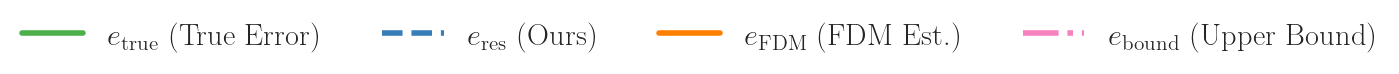

In [8]:
import matplotlib.lines as mlines
legend_handles = [
    mlines.Line2D([], [], color='#4daf4a',   linestyle='-',  lw=4, label=r'$e_{\mathrm{true}}$ (True Error)'),
    mlines.Line2D([], [], color='#377eb8',  linestyle='--', lw=4, label=r'$e_{\mathrm{res}}$ (Ours)'),
    mlines.Line2D([], [], color='#ff7f00', linestyle='-',  lw=4, label=r'$e_{\mathrm{FDM}}$ (FDM Est.)'),
    mlines.Line2D([], [], color='#f781bf', linestyle='-.', lw=4, label=r'$e_{\mathrm{bound}}$ (Upper Bound)'),
]

fig_legend, ax_legend = plt.subplots(figsize=(12, 0.4))
ax_legend.axis('off')
fig_legend.legend(
    handles=legend_handles,
    loc='center',
    ncol=4,
    frameon=False,
)

fig_legend.savefig("../figures/heat_eq_error_comparison/legend.pdf", bbox_inches='tight', pad_inches=0.05)